In [1]:
import os
import dill
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Defining the Hamiltonian

In [2]:
### for contour plots:
def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]  # Normalize to total probability 1
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)

In [3]:
### using approach from V1298Tau paper 
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    print(f'tau: {tau[0]}') 
    print(f'omega: {omega[0]}')
    print(f'e: {e[0]}')
    print(f'Tc: {Tc[0]}')
    print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


In [4]:
import numpy as np
from scipy.optimize import minimize_scalar

def true_to_eccentric(f, e):
    """Convert true anomaly to eccentric anomaly."""
    return 2 * np.arctan2(np.sqrt(1 - e) * np.sin(f / 2),
                          np.sqrt(1 + e) * np.cos(f / 2))

def mean_anomaly_proj_sep(t, Tc_array, P_array, e_array, omega_array, inc_array):
    """
    Compute mean anomaly at time t for an array of orbital parameter samples.
    All orbital parameters must be 1D numpy arrays of the same length.
    t is a scalar (single observation time).
    Returns 
        M_t: array of mean anomalies at time t, same length as input arrays.
    """

    n = len(Tc_array)
    M_t = np.zeros(n)
    tau = np.zeros(n)

    for i in range(n):
        Tc = float(Tc_array[i])
        P = float(P_array[i])
        e = float(e_array[i])
        omega = float(omega_array[i])
        inc = float(inc_array[i])

        # Minimize projected separation to find f_c
        def projected_sep(f):
            r = (1 - e**2) / (1 + e * np.cos(f))
            return r * np.sqrt(1 - (np.sin(omega + f) ** 2) * (np.sin(inc) ** 2))

        result = minimize_scalar(projected_sep, bounds=(0, 2 * np.pi), method='bounded')
        f_c = result.x

        E_c = true_to_eccentric(f_c, e) % (2 * np.pi)
        M_c = E_c - e * np.sin(E_c)
        # tau = Tc - (P / (2 * np.pi)) * M_c
        tau[i] = Tc - (P / (2 * np.pi)) * M_c
        M_t[i] = ((2 * np.pi / P) * (t - tau[i])) % (2 * np.pi)

    # print(tau[0], Tc_array[0], P_array[0], e_array[0], omega_array[0], inc_array[0] )
    print(f'tau: {tau[0]}') 
    print(f'omega: {omega_array[0]}')
    print(f'e: {e_array[0]}')
    print(f'Tc: {Tc_array[0]}')
    print(f'P: {P_array[0]}')
    print(f'inc: {inc_array[0]}')

    return M_t


In [5]:
def Lambda_k(mk,ak,mu):
    Lambda_k = mk*np.sqrt(mu*ak)
    return Lambda_k

def Ck(Lambda_k, ek):
    Ck = Lambda_k*(1 - np.sqrt(1-ek**2))
    return Ck

def Gamma_(p,Lambda1, Lambda2):
    Gamma = ((p+1)/p)*Lambda1 + Lambda2
    return Gamma

def G_(Lambda1, Lambda2, C1, C2):
    G = Lambda1 + Lambda2 - C1 - C2
    return G


In [6]:
def theta_res_(p, lambda1, lambda2):
    theta_res = (p+1)*lambda2 - p*lambda1
    return theta_res

def xk(Ck, pomega_k, theta_res):
    xk = np.sqrt(Ck) * np.exp(1j * (pomega_k - theta_res))
    return xk


In [7]:
#--- Laplace coefficient b_s^k(alpha) integral ---
from scipy.integrate import quad
def b(s, k, alpha):
    alpha = float(alpha)
    # Integrand for Laplace coefficient (eq. A10)
    def integrand(phi):
        denom = (1 - 2*alpha*np.cos(phi) + alpha**2)**s
        return np.cos(k*phi) / denom
    integral, _ = quad(integrand, -np.pi, np.pi, limit=200)
    # For k=0 factor 1/2 applies inside the integral by definition
    if k == 0:
        return integral / (2 * np.pi)
    else:
        return integral / np.pi


def script_R1_(alpha, p):
    factor = alpha / 4
    term1 = 3*b(3/2,p,alpha)
    term2 = 2*alpha*b(3/2, p+1, alpha)
    term3 = b(3/2, p+2, alpha)
    script_R1 = -factor*(term1 - term2 - term3)
    # script_R1 = -(alpha/4) * (3*b(3/2,p,alpha) - 2*alpha*b(3/2,p+1,alpha) - b(3/2,p+2,alpha))
    return script_R1

def script_R2_(alpha, p):
    factor = alpha /4
    term1 = 3*b(3/2, p-1, alpha)
    term2 = 2*alpha*b(3/2, p, alpha)
    term3 = b(3/2,p+1,alpha)
    term4 = (1/2)*b(1/2,p,alpha)
    script_R2 = factor*(term1 - term2 - term3) + term4
    # script_R2 = (alpha/4) * (3*b(3/2,p-1,alpha) - 2*alpha*b(3/2,p,alpha) - b(3/2,p+1,alpha)) + (1/2)*b(1/2,p,alpha)
    return script_R2


In [8]:
def R1_(gamma, mu, m2, Lambda1, Lambda2, script_R1):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3)/(Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda1)
    R1 = -term1*term2*term3*script_R1
    # R1 = -(gamma/(1+gamma))*((mu**2*m2**3)/(Lambda2**2))*(1/2)*np.sqrt(2/Lambda1)*script_R1
    return R1

def R2_(gamma, mu, m2, Lambda2, script_R2):
    term1 = gamma / (1+gamma)
    term2 = (mu**2 * m2**3) / (Lambda2**2)
    term3 = (1/2)*np.sqrt(2/Lambda2)
    R2 = -term1*term2*term3*script_R2
    # R2 = -(gamma/(1+gamma)) * ((mu**2 * m2**3)/(Lambda2**2)) * (1/2)*np.sqrt(2/Lambda2)*script_R2
    return R2


In [9]:
def I1_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R1**2 * C1
    term2 = R2**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2)*np.cos(Delta_pomega)
    I1 = factor* (term1 + term2 + term3)
    # I1 = (1/(R1**2 + R2**2))*(R1**2*C1 + R2**2*C2 + 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I1

def I2_(R1, R2, C1, C2, Delta_pomega):
    factor = 1/(R1**2 + R2**2)
    term1 = R2**2 * C1
    term2 = R1**2 * C2
    term3 = 2*R1*R2* np.sqrt(C1*C2) * np.cos(Delta_pomega)
    I2 = factor*(term1 + term2 - term3)
    # I2 = (1/(R1**2 + R2**2))*(R2**2*C1 + R1**2*C2 - 2*R1*R2*np.sqrt(C1*C2)*np.cos(Delta_pomega))
    return I2


In [10]:
def K2_(P2, Lambda2, p, gamma, alpha):
    n2 = (2*np.pi)/P2
    K2 = -((3*n2)/(2*Lambda2)) * (p+1)**2 * ((gamma+alpha)/alpha)
    return K2

def Delta_G_(Gamma, p, gamma, alpha_0,G):
    Delta_G = (Gamma/(p+1)) * ((p*gamma + (p+1)*alpha_0)/(gamma+alpha_0)) - G
    return Delta_G


In [11]:
### defining theta1 (argument of y1)

def y1_(x1, x2, R1, R2):
    term1 = (R1/(np.sqrt(R1**2 + R2**2))) * x1
    term2 = (R2/(np.sqrt(R1**2 + R2**2))) * x2
    y1 = term1 + term2
    return y1


In [12]:
def hamiltonian(K2, I1, I2, Delta_G, eps, R1, R2, theta1):
    H = (K2)*(I1 + I2 - Delta_G)**2 + 2*eps*np.sqrt(R1**2 + R2**2)*np.sqrt(I1)*np.cos(theta1)
    return H


# Defining Y1 and Y2

In [13]:
def Y1_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
    numerator = (e_tilda_1*np.exp(1j * pomega_1)) - (1.22*e_tilda_2*np.exp(1j * pomega_2))
    denominator = np.sqrt(1 + 1.31*gamma)
    Y1 = (numerator/denominator) * np.exp(-1j * theta_res)
    return Y1


In [14]:
def Y2_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, gamma, theta_res):
    numerator = (1.07*gamma*e_tilda_1*np.exp(1j * pomega_1)) + (e_tilda_2*np.exp(1j * pomega_2))
    denominator = np.sqrt(1 + 1.31*gamma)
    Y2 = (numerator/denominator) * np.exp(-1j * theta_res)
    return Y2


## make the posterior distribution plot for Y1

In [43]:
### get the posterior data
# file_name = 'data/jnkep_fit_k2-19_nburn-1000_nsteps-1000_emax=0.5.pkl'
# file_name = 'data/jnkep_fit_k2-19_nburn-1000_nsteps-1000_accept-90_tree-11_hessian_emax-0.5.pkl'
file_name = 'jnkep_fit_k2-19_nburn-1000_nsteps-1000_accept-90_tree-11_hessian_emax-0.5.pkl'


working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [44]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.38      0.10      0.38      0.22      0.53    331.12      1.01
 ecosw_scaled[1]      0.43      0.08      0.43      0.30      0.55    329.24      1.01
 esinw_scaled[0]      0.43      0.14      0.45      0.19      0.64    438.06      1.01
 esinw_scaled[1]      0.34      0.11      0.35      0.14      0.51    433.29      1.01
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    378.09      1.01
period_scaled[1]      0.51      0.01      0.52      0.51      0.52    373.77      1.01
 pmass_scaled[0]      0.11      0.00      0.10      0.10      0.11    334.64      1.01
 pmass_scaled[1]      0.04      0.00      0.04      0.04      0.04    620.07      1.00
   tic_scaled[0]      0.50      0.00      0.50      0.50      0.50   1662.51      1.00
   tic_scaled[1]      0.50      0.00      0.50      0.50      0.51    767.27      1.00

Number of divergences: 58


In [45]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})

samples = mcmc.get_samples()

{'ecc': (4000, 2), 'ecosw': (4000, 2), 'ecosw_scaled': (4000, 2), 'ediff': (4000,), 'esinw': (4000, 2), 'esinw_scaled': (4000, 2), 'period': (4000, 2), 'period_scaled': (4000, 2), 'pmass': (4000, 2), 'pmass_scaled': (4000, 2), 'tcmodel': (4000, 30), 'tic': (4000, 2), 'tic_scaled': (4000, 2)}


In [46]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.88  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
e_b = samples["ecc"][:,0]
P_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
m_b = samples["pmass"][:,0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
e_c = samples["ecc"][:,1]
P_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
m_c = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_b = np.array(((G_const*m_star*P_b**2)/(4*np.pi**2))**(1.0/3)) # [AU]
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1/3)) # [AU]


omega_b = np.arctan2(esinw_b, ecosw_b) # [rad]
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]

# times = np.array([1980.] * len(omega_b))
times = Tc_c

Mean_anomaly_b = mean_anomaly(times, omega_b, e_b, Tc_b, P_b)
Mean_anomaly_c = mean_anomaly(times, omega_c, e_c, Tc_c, P_c)
e_tilda_b = np.sqrt(2*(1 - np.sqrt(1 - e_b**2)))
e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))

### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_c)  # [rad]

pomega_b = omega_b + Omega_b
pomega_c = omega_c + Omega_c
lambda_b = omega_b + Omega_b + Mean_anomaly_b
lambda_c = omega_c + Omega_c + Mean_anomaly_c
p = np.array([2] * len(lambda_b))
theta_res = theta_res_(p, lambda_b, lambda_c)

# print(a_b)
# print(a_c)
print(e_tilda_b)
print(e_tilda_c)
print(e_b)
print(e_c)
print(pomega_b)
print(pomega_c)
print(theta_res)

tau: 1975.4708251953125
omega: -2.108736038208008
e: 0.18772269785404205
Tc: 1980.3837890625
P: 7.9197893142700195
tau: 1977.431884765625
omega: -1.8948315382003784
e: 0.19694514572620392
Tc: 1984.2733154296875
P: 11.903742790222168
[0.18856256 0.17925708 0.08216193 ... 0.12850891 0.14678192 0.12220549]
[0.1979166  0.18945187 0.10537659 ... 0.08073196 0.14576483 0.10734417]
[0.1877227  0.17853567 0.08209246 ... 0.12824354 0.14638607 0.12197728]
[0.19694515 0.18859999 0.10523029 ... 0.08066605 0.14537728 0.10718949]
[-2.10873604 -2.12060618 -2.34752035 ...  2.73561525 -2.53245544
 -2.97072363]
[-1.89483154 -1.89708686 -1.88448668 ... -3.02661657 -2.16392517
 -2.44000602]
[ 7.965785   7.965462   7.935545  ... -4.5715837  7.9908133  7.995077 ]


In [47]:
eps = (m_b+m_c)/m_star
mu = np.array([G_const*m_star] * len(omega_b))
gamma = m_b/m_c 
alpha = a_b/a_c 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_c - pomega_b # ??

print(alpha)
print(alpha_0)
print(Delta_pomega)

[0.76211417 0.76207525 0.7619791  ... 0.7619579  0.76203823 0.7620072 ]
[0.76314283 0.76314283 0.76314283 ... 0.76314283 0.76314283 0.76314283]
[ 0.2139045   0.22351933  0.46303368 ... -5.76223183  0.36853027
  0.53071761]


## Plotting Posterior distribution for Y1

In [48]:
Y1 = Y1_(e_tilda_b, e_tilda_c, pomega_b, pomega_c, gamma, theta_res)
print(np.median(Y1))

(0.030103898635915095+0.005697291922418569j)


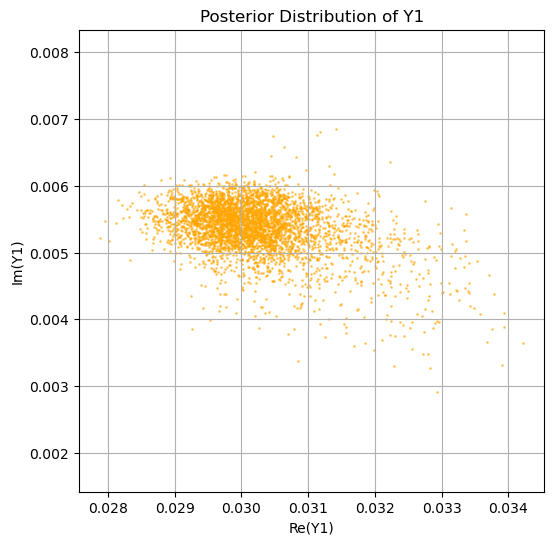

In [49]:
import matplotlib.pyplot as plt

# Extract real and imaginary parts
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

plt.figure(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.5,color='orange')  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y1)")
plt.ylabel("Im(Y1)")
plt.title("Posterior Distribution of Y1")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

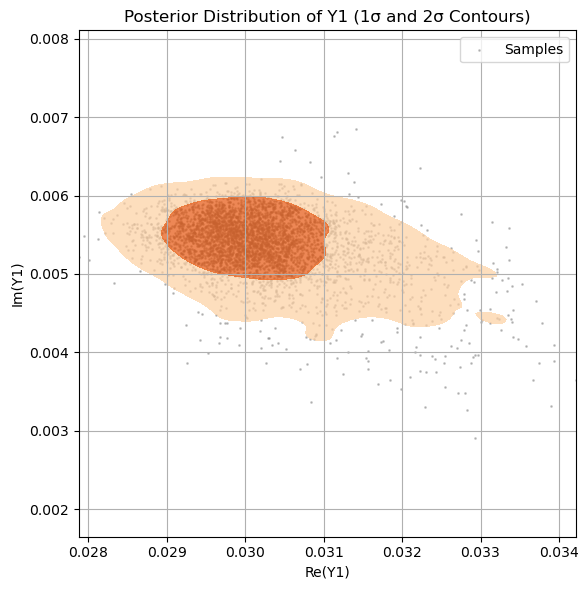

In [50]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np

def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]  # Normalize to total probability 1
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)

# Extract real and imaginary parts of Y1
Y1_real = np.real(Y1)
Y1_imag = np.imag(Y1)

# Compute KDE and contour levels
X_1, Y_1, Z_1 = compute_kde_contour_levels(Y1_real, Y1_imag)
levels_1 = get_sigma_contour_levels(Z_1)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y1_real, Y1_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_1, Y_1, Z_1, levels=levels_1 + [Z_1.max()], colors=["#fdd0a2", "#e6550d"], alpha=0.7)

# Plot formatting
ax.set_xlabel("Re(Y1)")
ax.set_ylabel("Im(Y1)")
ax.set_title("Posterior Distribution of Y1 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()


## Plotting posterior distribution for Y2

In [51]:
Y2 = Y2_(e_tilda_b, e_tilda_c, pomega_b, pomega_c, gamma, theta_res)
print(Y2)

[-0.29412585+0.19934638j -0.28205305+0.19554722j -0.1191224 +0.10438693j
 ...  0.09548414+0.19217336j -0.14287937+0.22625823j
 -0.03156359+0.21021362j]


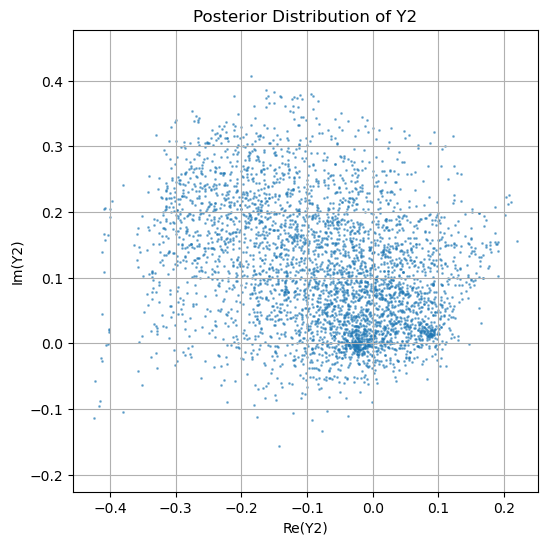

In [52]:
import matplotlib.pyplot as plt

# Extract real and imaginary parts
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

plt.figure(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.5)  # Adjust s for point size, alpha for transparency
plt.xlabel("Re(Y2)")
plt.ylabel("Im(Y2)")
plt.title("Posterior Distribution of Y2")
plt.grid(True)
plt.axis('equal')  # Optional: ensures square aspect ratio
plt.show()

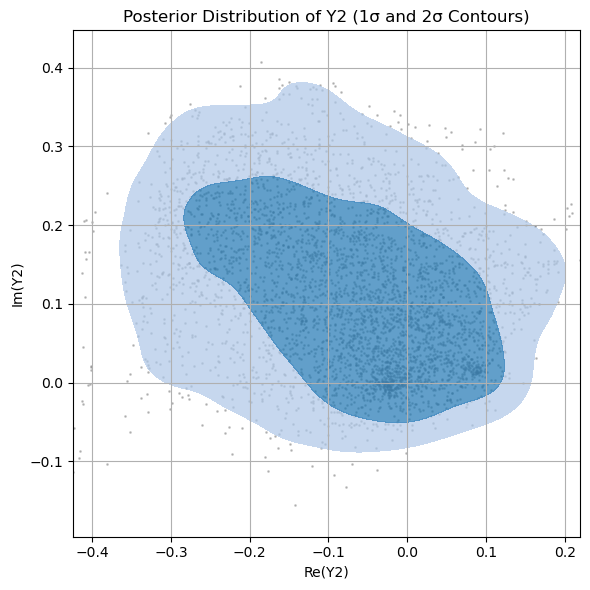

In [53]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np

def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]  # Normalize to total probability 1
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)

# Extract real and imaginary parts of Y1
Y2_real = np.real(Y2)
Y2_imag = np.imag(Y2)

# Compute KDE and contour levels
X_2, Y_2, Z_2 = compute_kde_contour_levels(Y2_real, Y2_imag)
levels_2 = get_sigma_contour_levels(Z_2)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(Y2_real, Y2_imag, s=1, alpha=0.4, color='grey',label='Samples')

contour = ax.contourf(X_2, Y_2, Z_2, levels=levels_2 + [Z_2.max()], colors=["#aec7e8", "#1f77b4"], alpha=0.7)

# Plot formatting
ax.set_xlabel("Re(Y2)")
ax.set_ylabel("Im(Y2)")
ax.set_title("Posterior Distribution of Y2 (1σ and 2σ Contours)")
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93087/3231928961.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_1$', xy=(0.03, 0.0055), xytext=(0.1, 0.0055 + 0.4), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93087/3231928961.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_2$', xy=(-0.1, 0.15), xytext=(-0.25, 0.05 + 0.4), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)


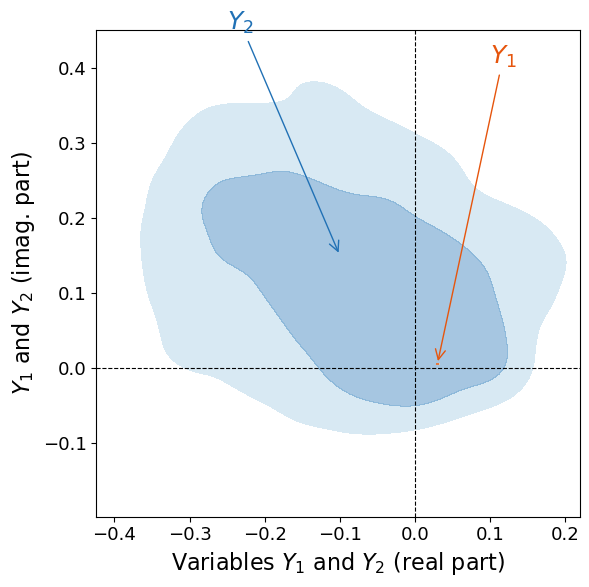

In [54]:
# Plot Y1 and Y2 together
fig, ax = plt.subplots(figsize=(6, 6))
contour = ax.contourf(X_2, Y_2, Z_2, 
                      levels=levels_2 + [Z_2.max()], 
                      colors=['#9ecae1', '#2171b5'], 
                      alpha=0.4)
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)

# Plot formatting
ax.set_xlabel("Variables $Y_1$ and $Y_2$ (real part)", fontsize=16)
ax.set_ylabel("$Y_1$ and $Y_2$ (imag. part)", fontsize=16)
# ax.set_title("Posterior Distribution of Y1 and Y2 (1σ and 2σ Contours)")
# ax.grid(True)
ax.axis('equal')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Annotations and arrows
ax.annotate('$Y_1$', xy=(0.03, 0.0055), xytext=(0.1, 0.0055 + 0.4), arrowprops=dict(facecolor='#e6550d', arrowstyle='->',color='#e6550d'), color='#e6550d', fontsize=18)
ax.annotate('$Y_2$', xy=(-0.1, 0.15), xytext=(-0.25, 0.05 + 0.4), arrowprops=dict(facecolor='#2171b5', arrowstyle='->',color='#2171b5'),color='#2171b5', fontsize=18)
plt.tick_params(axis='both', labelsize=13) 
plt.tight_layout()
plt.show()

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93087/2853894012.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_1$', xy=(0.03, 0.0055), xytext=(0.1, 0.3),
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93087/2853894012.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('$Y_2$', xy=(-0.1, 0.15), xytext=(-0.25, 0.4),
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_93087/2853894012.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


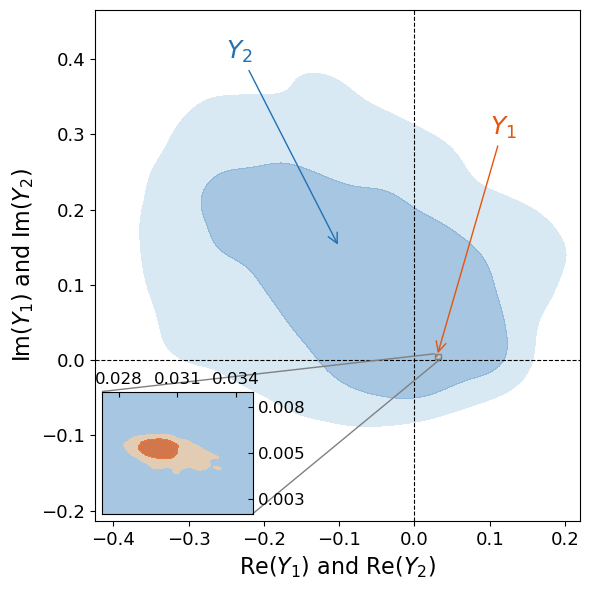

In [61]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
import matplotlib.ticker as mticker

# Plot Y1 and Y2 together
fig, ax = plt.subplots(figsize=(6, 6))
contour = ax.contourf(X_2, Y_2, Z_2, 
                      levels=levels_2 + [Z_2.max()], 
                      colors=['#9ecae1', '#2171b5'], 
                      alpha=0.4)
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)

# Plot formatting
ax.set_xlabel("Re($Y_1$) and Re($Y_2$)", fontsize=16)
ax.set_ylabel("Im($Y_1$) and Im($Y_2$)", fontsize=16)
ax.axis('equal')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)

# Annotations and arrows
ax.annotate('$Y_1$', xy=(0.03, 0.0055), xytext=(0.1, 0.3), 
            arrowprops=dict(facecolor='#e6550d', arrowstyle='->', color='#e6550d'),
            color='#e6550d', fontsize=18)
ax.annotate('$Y_2$', xy=(-0.1, 0.15), xytext=(-0.25, 0.4), 
            arrowprops=dict(facecolor='#2171b5', arrowstyle='->', color='#2171b5'),
            color='#2171b5', fontsize=18)

# Create a zoomed inset for Y1
axins = zoomed_inset_axes(ax, zoom=25, loc="lower left")  # zoom factor, location
axins.contourf(X_2, Y_2, Z_2, 
               levels=levels_2 + [Z_2.max()], 
               colors=['#9ecae1', '#2171b5'], 
               alpha=0.4)
axins.contourf(X_1, Y_1, Z_1, 
               levels=levels_1 + [Z_1.max()], 
               colors=["#fdd0a2", "#e6550d"], 
               alpha=0.7)
#Enable ticks and labels but place them on top/right
axins.tick_params(
    axis="both", which="both",
    top=True, right=True,      # show ticks here
    bottom=False, left=False,  # hide on overlapping sides
    labeltop=True, labelright=True,
    labelbottom=False, labelleft=False,
    labelsize=12, direction="in"
)
# Slight offset for first and last ticks
x_offset = 0.0009
y_offset = 0.0008

x1, x2, y1, y2 = 0.027, 0.035, 0.002, 0.0085  # region of interest

# Set tick positions
xticks = [x1 + x_offset, (x1 + x2)/2, x2 - x_offset]
yticks = [y1 + y_offset, (y1 + y2)/2, y2 - y_offset]

axins.set_xticks(xticks)
axins.set_yticks(yticks)

# Format tick labels to 3 decimal places
axins.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
axins.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# Set zoomed region (adjust limits around Y1)
# x1, x2, y1, y2 = 0.027, 0.035, 0.002, 0.0085  # region of interest
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)  # hide tick labels

# Draw a box connecting inset and main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.tick_params(axis='both', labelsize=13) 
plt.tight_layout()
plt.show()


## Hamiltonian

In [27]:
### calculated params 
eps = (m_b+m_c)/m_star
mu = np.array([G_const*m_star] * len(omega_b)) # as defined in paper, is this different from mu from posteriors?
gamma = m_b/m_c 
alpha = a_b/a_c 
alpha_0 = (p/(p+1))**(2/3)
Delta_pomega = pomega_b - pomega_c # ??

### use definitions to define other variables for hamiltonian
Lambda_b = Lambda_k(m_b, a_b, mu)
Lambda_c = Lambda_k(m_c, a_c, mu)

C_b = Ck(Lambda_b, e_b)
C_c = Ck(Lambda_c, e_c)

Gamma = Gamma_(p, Lambda_b,Lambda_c)
G = G_(Lambda_b, Lambda_c, C_b, C_c)

theta_res = theta_res_(p, lambda_b, lambda_c)

x_b = xk(C_b, pomega_b, theta_res)
x_c = xk(C_c, pomega_c, theta_res)

e_tilda_b = np.sqrt(2*(1 - np.sqrt(1 - e_b**2)))
e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - e_c**2)))

script_R1 = np.array([script_R1_(a, p_val) for a, p_val in zip(alpha_0, p)])
script_R2 = np.array([script_R2_(a, p_val) for a, p_val in zip(alpha_0, p)])

R1 = R1_(gamma, mu, m_c, Lambda_b, Lambda_c, script_R1)
R2 = R2_(gamma, mu, m_c, Lambda_c, script_R2)

I1 = I1_(R1, R2, C_b, C_c, Delta_pomega)
I2 = I2_(R1, R2, C_b, C_c, Delta_pomega)

K2 = K2_(P_c, Lambda_c, p, gamma, alpha_0)

Delta_G = Delta_G_(Gamma, p, gamma, alpha_0, G)

y1 = y1_(x_b,x_c,R1,R2)
theta1 = np.angle(y1)
print(f'Y1 before: {Y1}')
# Y1 = np.sqrt(2/Lambda_b) * y1
print(f'Y1: {Y1}')

print(f'alpha: {alpha}')
print(f'alpha_0: {alpha_0}')
print(f"eps: {eps}")

print(f"Lambda_b: {Lambda_b}")
print(f"Lambda_c: {Lambda_c}")
print(f"gamma: {gamma}")
print(f"mu: {mu}")
print(f"m_c: {m_c}")
print(f"script_R1: {script_R1}")
print(f"script_R2: {script_R2}")

print(f"K2 = {K2}")
print(f"I1 = {I1}")
print(f"I2 = {I2}")
print(f"Delta_G = {Delta_G}")
print(f"eps = {eps}")
print(f"R1 = {R1}")
print(f"R2 = {R2}")
print(f"theta1: {theta1}")

Y1 before: [0.02981124+0.00509927j 0.02951111+0.0051432j  0.0295971 +0.00519531j ...
 0.02943414+0.00570325j 0.02992055+0.00572335j 0.02995924+0.00578053j]
Y1: [0.02981124+0.00509927j 0.02951111+0.0051432j  0.0295971 +0.00519531j ...
 0.02943414+0.00570325j 0.02992055+0.00572335j 0.02995924+0.00578053j]
alpha: [0.7618658  0.76186895 0.7618824  ... 0.76193404 0.7619558  0.76199114]
alpha_0: [0.76314283 0.76314283 0.76314283 ... 0.76314283 0.76314283 0.76314283]
eps: [0.0001577  0.00015701 0.00015782 ... 0.00015761 0.00015865 0.00016207]
Lambda_b: [4.4954697e-07 4.4886011e-07 4.5280382e-07 ... 4.4957068e-07 4.4855446e-07
 4.6256108e-07]
Lambda_c: [1.8530756e-07 1.8299944e-07 1.8211215e-07 ... 1.8488491e-07 1.9066654e-07
 1.8979270e-07]
gamma: [2.7793465 2.8100953 2.848572  ... 2.7857223 2.695106  2.791995 ]
mu: [0.0002604 0.0002604 0.0002604 ... 0.0002604 0.0002604 0.0002604]
m_c: [3.6720212e-05 3.6262874e-05 3.6087287e-05 ... 3.6637768e-05 3.7783990e-05
 3.7611455e-05]
script_R1: [-2.02

K2_val = -176718160.0
I1_val = 2.1527590821079912e-10
I2_val = 2.7764461840718013e-09
Delta_G_val = 2.9529019229812548e-09
eps_val = 0.00016123904788400978
R1_val = 0.0001547245483379811
R2_val = -0.0002964387822430581


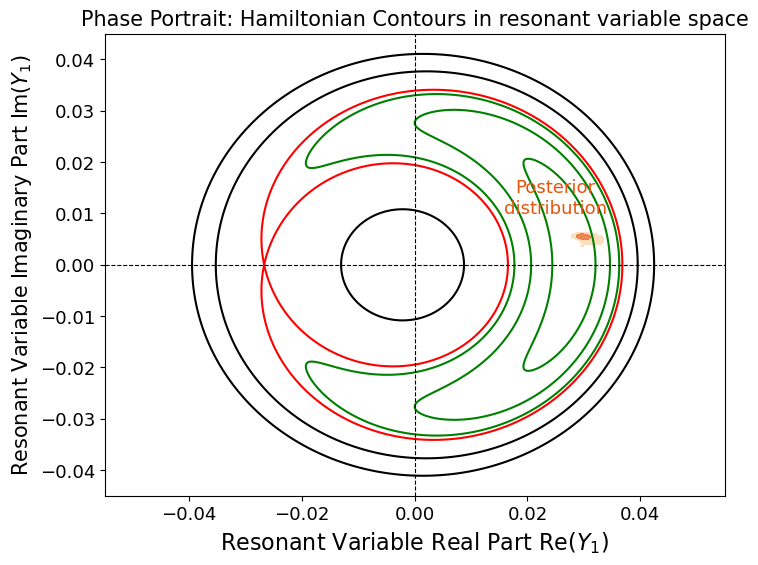

In [28]:
I1_val = np.median(I1)
I2_val = np.median(I2)
R1_val = np.median(R1)
R2_val = np.median(R2)
K2_val = np.median(K2)
Delta_G_val = np.median(Delta_G)
eps_val = np.median(eps)
print(f"K2_val = {K2_val}")
print(f'I1_val = {I1_val}')
print(f"I2_val = {I2_val}")
print(f"Delta_G_val = {Delta_G_val}")
print(f"eps_val = {eps_val}")
print(f"R1_val = {R1_val}")
print(f"R2_val = {R2_val}")

# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.02, I1.max()*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 8000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)

y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_b)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]

contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)


### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title('Phase Portrait: Hamiltonian Contours in resonant variable space', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
plt.xlim(-0.055,0.055)
plt.ylim(-0.045, 0.045)
# plt.legend()
plt.show()

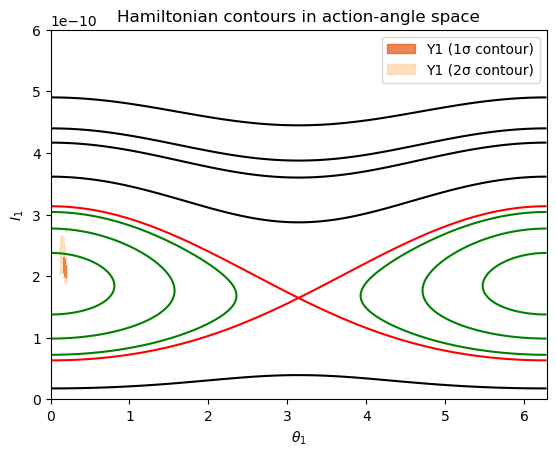

In [29]:
# plt.contour(theta1_grid, I1_grid, H_grid, levels=50, cmap='RdYlBu')
plt.contour(theta1_grid, I1_grid, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

levels_circulating=[-0.15*10**(-10), -0.1*10**(-10), -0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_circulating, colors='black',linestyles='-')
plt.contour(theta1_grid, I1_grid, H_grid, levels=levels_resonant, colors='green',linestyles='-')


# scatter_pts = plt.scatter((theta1)%(2*np.pi), I1, s=1, c='grey',alpha=0.7, label='calculated values')

### add Y1 posterior distribution in theta1-I1 space
im_Y1 = Y_1
re_Y1 = X_1
Y_1_complex = re_Y1 + 1j * im_Y1
theta1_back = np.angle(Y_1_complex)  # θ in [-π, π]
I1_back = (np.median(Lambda_b) / 2) * np.abs(Y_1_complex)**2

# Wrap θ into [0, 2π] for cleaner plotting
theta1_back = np.mod(theta1_back, 2 * np.pi)

plt.contourf(theta1_back, I1_back, Z_1, 
             levels=levels_1 + [Z_1.max()], 
             colors=["#fdd0a2", "#e6550d"], 
             alpha=0.7)

import matplotlib.patches as mpatches
# Custom legend patches
orange_1sigma = mpatches.Patch(color="#e6550d", alpha=0.7, label="Y1 (1σ contour)")
orange_2sigma = mpatches.Patch(color="#fdd0a2", alpha=0.7, label="Y1 (2σ contour)")

# Add legend
# plt.legend(handles=[scatter_pts, orange_1sigma, orange_2sigma], loc="upper right")
plt.legend(handles=[orange_1sigma, orange_2sigma], loc="upper right")

plt.ylim(0, 0.6e-9)
# plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$I_1$')
plt.title('Hamiltonian contours in action-angle space')
plt.show()

In [30]:
# Compute the two components of H separately
H_kinetic =  (K2_val/2) * (I1_grid + I2_val - Delta_G_val)**2
H_resonant = 2 * eps_val * np.sqrt(R1_val**2 + R2_val**2) * np.sqrt(I1_grid) * np.cos(theta1_grid)

print("Typical kinetic H:", np.median(H_kinetic))
print("Typical resonant H:", np.median(H_resonant))


Typical kinetic H: -3.7905875683161855e-11
Typical resonant H: 4.072904431039035e-17


In [31]:
print(f'Median Y1: {np.median(Y1)}')
print(f'Median Re(Y1): {np.real(np.median(Y1))}')
print(f'Median Im(Y1): {np.imag(np.median(Y1))}')
Y1_median = np.median(Y1)
Re_Y1_median = np.real(np.median(Y1))
Im_Y1_median = np.imag(np.median(Y1))
print(Y1)
print(Y1_median)
dist=np.abs(Y1-Y1_median)
print(dist)
median_idx = np.argmin(dist)
print(median_idx)

e_b_medianY1 = e_b[median_idx]
e_c_medianY1 = e_c[median_idx]
e_tilda_b_medianY1 = np.sqrt(2*(1 - np.sqrt(1 - e_b_medianY1**2)))
e_tilda_c_medianY1 = np.sqrt(2*(1 - np.sqrt(1 - e_c_medianY1**2)))

pomega_b_medianY1 = pomega_b[median_idx]
pomega_c_medianY1 = pomega_c[median_idx]
m_b_medianY1 = m_b[median_idx]
m_c_medianY1 = m_c[median_idx]
gamma_medianY1 = m_b_medianY1 / m_c_medianY1
lambda_b_medianY1 = lambda_b[median_idx]
lambda_c_medianY1 = lambda_c[median_idx]
theta_res_medianY1 = theta_res_(p[0], lambda_b_medianY1, lambda_c_medianY1)


Y1_test = Y1_(e_tilda_b_medianY1, e_tilda_c_medianY1, pomega_b_medianY1, pomega_c_medianY1, gamma_medianY1, theta_res_medianY1)
print(Y1_test)
print(Y1_test - Y1_median)

Median Y1: (0.03001498804573759+0.005418364170401296j)
Median Re(Y1): 0.03001498804573759
Median Im(Y1): 0.005418364170401296
[0.02981124+0.00509927j 0.02951111+0.0051432j  0.0295971 +0.00519531j ...
 0.02943414+0.00570325j 0.02992055+0.00572335j 0.02995924+0.00578053j]
(0.03001498804573759+0.005418364170401296j)
[0.00037859 0.00057412 0.00047369 ... 0.00064695 0.00031928 0.00036643]
6363
(0.03001307506162944+0.005415830092550695j)
(-1.912984108148885e-06-2.534077850600315e-06j)


## Running Rebound

In [32]:
### initialize simulation at values near the median Y1 values
m_b_val = m_b[median_idx]
m_c_val = m_c[median_idx]
a_b_val = a_b[median_idx]
a_c_val = a_c[median_idx]
e_b_val = e_b[median_idx]
e_c_val = e_c[median_idx]
lambda_b_val = lambda_b[median_idx]
lambda_c_val = lambda_c[median_idx]
pomega_b_val = pomega_b[median_idx]
pomega_c_val = pomega_c[median_idx]
P_b_val = P_b[median_idx]

In [40]:
### time settings 
# t_max = 1e4 * P_b_val
# t_max = 1e6 * P_b_val
t_max = 1e4 * P_b_val

Nout = 20000
times = np.linspace(0,t_max,Nout)


In [41]:
### set up simulation 
import rebound
sim = rebound.Simulation()
sim.add(m=m_star)

### initialize with median values from posteriors?
sim.add(m=m_b_val, a=a_b_val, e=e_b_val, l=lambda_b_val, pomega=pomega_b_val)
sim.add(m=m_c_val, a=a_c_val, e=e_c_val, l=lambda_c_val, pomega=pomega_c_val)

sim.move_to_com()

In [42]:
def compute_resonant_vars(sim):
    p = 2  # for 3:2 resonance
    star = sim.particles[0]
    p1 = sim.particles[1]
    p2 = sim.particles[2]
    mu = G_const*m_star

    # Get osculating orbital elements relative to star
    o1 = p1.orbit()
    o2 = p2.orbit()

    alpha_ = o1.a / o2.a
    gamma_ = p1.m / p2.m
    eps_ = (p1.m + p2.m) / m_star
    Delta_pomega_ = o2.pomega - o1.pomega
    P_c = 2*np.pi*np.sqrt(o2.a**3/(G_const*m_star))

    Lambda_b = Lambda_k(p1.m, o1.a, mu)
    Lambda_c = Lambda_k(p2.m, o2.a, mu)
    
    C_b = Ck(Lambda_b, o1.e)
    C_c = Ck(Lambda_c, o2.e)

    Gamma = Gamma_(p, Lambda_b,Lambda_c)
    G = G_(Lambda_b, Lambda_c, C_b, C_c)

    theta_res = theta_res_(p, o1.l, o2.l)

    x_b = xk(C_b, o1.pomega, theta_res)
    x_c = xk(C_c, o2.pomega, theta_res)
    
    script_R1 = script_R1_(alpha_, p)
    script_R2 = script_R2_(alpha_, p)
    
    R1 = R1_(gamma_, mu, p2.m, Lambda_b, Lambda_c, script_R1)
    R2 = R2_(gamma_, mu, p2.m, Lambda_c, script_R2)

    K2 = K2_(P_c, Lambda_c, p, gamma_, alpha_)
    Delta_G = Delta_G_(Gamma, p, gamma_, alpha_, G)
    
    I1 = I1_(R1, R2, C_b, C_c, Delta_pomega_)
    I2 = I2_(R1, R2, C_b, C_c, Delta_pomega_)

    y1 = y1_(x_b,x_c,R1,R2)
    theta1 = np.angle(y1)

    e_tilda_b = np.sqrt(2*(1 - np.sqrt(1 - o1.e**2)))
    e_tilda_c = np.sqrt(2*(1 - np.sqrt(1 - o2.e**2)))

    Y1 = Y1_(e_tilda_b, e_tilda_c, o1.pomega, o2.pomega, gamma_, theta_res)
    Y2 = Y2_(e_tilda_b, e_tilda_c, o1.pomega, o2.pomega, gamma_, theta_res)

    H = hamiltonian(K2, I1, I2, Delta_G, eps_, R1, R2, theta1)

    ### tracking eccentricities
    eb_ = o1.e
    ec_ = o2.e

    phi_1 = theta_res - o1.pomega
    phi_2 = theta_res - o2.pomega

    return H, Y1, Y2, I1, I2, theta1, eb_, ec_, Delta_pomega_, phi_1, phi_2


In [43]:
sim.integrate(0)
Hi, Y1i, Y2i, I1i, I2i, theta1i, ebi, eci, Delta_pomegai, phi_1i, phi_2i = compute_resonant_vars(sim)
print('initial values:')
print(f'Hi {Hi}')
print(f'Y1i: {Y1i}')
# print(f'intial Y1: {Y1[0]}')
print(f'Y2i: {Y2i}')
print(f'I1i: {I1i}')
print(f'I2i: {I2i}')
print(f'theta1i: {theta1i}')

initial values:
Hi -6.916096823398772e-13
Y1i: (0.03001324221529957+0.005415654663490158j)
Y2i: (-0.06061675043749656+0.11829429350679184j)
I1i: 2.1776634587145521e-10
I2i: 1.6553246651688305e-09
theta1i: 0.1711387741576689


In [44]:
if Hi > H_saddle:
    print("Initial point is outside separatrix")
else:
    print("Initial point is inside separatrix")

Initial point is outside separatrix


In [45]:
# sim.integrate(0)
star = sim.particles[0]
p1 = sim.particles[1]
p2 = sim.particles[2]

mu = G_const*m_star

# Get osculating orbital elements relative to star
o1 = p1.orbit()
o2 = p2.orbit()
print(p1.m)
print(m_b_val)
print(o1)
print(o2)

0.00010513668530620635
0.000105136685
<rebound.Orbit instance, a=0.07451137155294421 e=0.07209549844264988 inc=0.0 Omega=0.0 omega=3.5197137037860364 f=1.4157510142723613>
<rebound.Orbit instance, a=0.0977861136198044 e=0.08431168645620334 inc=0.0 Omega=0.0 omega=4.21275717416872 f=3.641242428955273>


In [46]:
H_vals = np.zeros(len(times))
Re_Y1_vals = np.zeros(len(times))
Im_Y1_vals = np.zeros(len(times))
Re_Y2_vals = np.zeros(len(times))
Im_Y2_vals = np.zeros(len(times))
I1_vals = np.zeros(len(times))
I2_vals = np.zeros(len(times))
theta1_vals = np.zeros(len(times))
eb_vals = np.zeros(len(times))
ec_vals = np.zeros(len(times))
Delta_pomega_vals = np.zeros(len(times))
phi1_vals = np.zeros(len(times))
phi2_vals = np.zeros(len(times))


for i, t in enumerate(times):
    sim.integrate(t)
    H_t, Y1_t, Y2_t, I1_t, I2_t, theta1_t, eb_t, ec_t, Delta_pomega_t, phi1_t, phi2_t = compute_resonant_vars(sim)
    # print(Y1)
    H_vals[i] = H_t
    Re_Y1_vals[i] = np.real(Y1_t)
    Im_Y1_vals[i] = np.imag(Y1_t)
    Re_Y2_vals[i] = np.real(Y2_t)
    Im_Y2_vals[i] = np.imag(Y2_t)
    I1_vals[i] = I1_t
    I2_vals[i] = I2_t
    theta1_vals[i] = theta1_t
    eb_vals[i] = eb_t
    ec_vals[i] = ec_t
    Delta_pomega_vals[i] = Delta_pomega_t
    phi1_vals[i] = phi1_t
    phi2_vals[i] = phi2_t


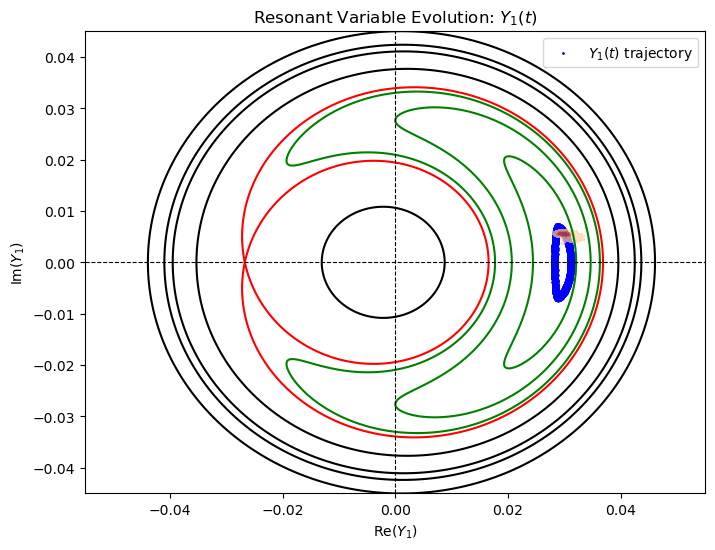

In [47]:
# Plot Y1 in Re/Im space
plt.figure(figsize=(8,6))

# use scatter? using plot doesn't show clear trajectory
plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')
# plt.scatter(Re_Y1_vals[0], Im_Y1_vals[0], color='orange', s=30, label='initial value')
contours_circ = plt.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black', linestyles='-')
contours_res = plt.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green', linestyles='-')
contour_sep = plt.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red', linestyles='-', linewidths=1.5)

### add Y1 posterior distribution
contour = plt.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# plt.scatter(Re_Y2_vals, Im_Y2_vals, c='red', s=1, label=r'$Y_2(t)$ trajectory')
# plt.scatter(Re_Y1_median, Im_Y1_median, color='purple',label='median Y1')


# Dashed axes
plt.axhline(0, color='black', linestyle='--', lw=0.8)
plt.axvline(0, color='black', linestyle='--', lw=0.8)

plt.xlim(-0.055,0.055)
plt.ylim(-0.045, 0.045)
plt.xlabel(r'Re$(Y_1)$')
plt.ylabel(r'Im$(Y_1)$')
plt.title(r'Resonant Variable Evolution: $Y_1(t)$')
# plt.grid(True)
plt.legend()
plt.show()


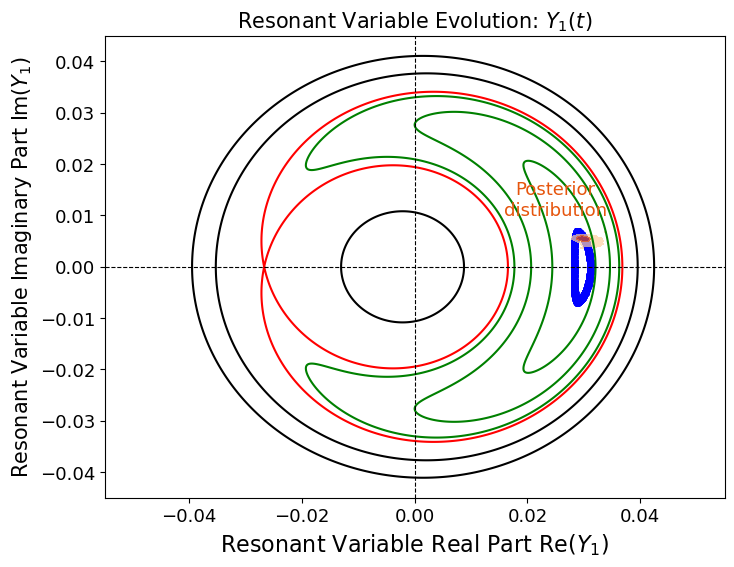

In [48]:
# Define grid for I1 and theta1
# I1_vals = np.linspace(I1_val*0.08, I1_val*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)
I1_vals = np.linspace(I1.min()*0.02, I1.max()*4, 8000)   # I1 must be >= 0, avoid 0 to prevent sqrt(0)

# I1_vals = np.linspace(0.000000001, 0.02, 8000)
theta1_vals = np.linspace(0, 2*np.pi, 8000)

I1_grid, theta1_grid = np.meshgrid(I1_vals, theta1_vals)


# Compute Hamiltonian on the grid
H_grid = hamiltonian(K2_val, I1_grid, I2_val, Delta_G_val, eps_val, R1_val, R2_val, theta1_grid)

y_1 = np.sqrt(I1_grid)*np.exp(1j*theta1_grid)
Y_1_ = np.sqrt(2/np.median(Lambda_b)) * y_1
Re_Y1 = np.real(Y_1_)
Im_Y1 = np.imag(Y_1_)

# Plot Hamiltonian contours in (Re_y1, Im_y1) space
fig, ax = plt.subplots(figsize=(8, 6))

levels_circulating=[-0.08*10**(-10), -0.04*10**(-10)]
levels_resonant = [-0.01*10**(-10), 0.0, 0.01*10**(-10)]

contours_circ = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_circulating, colors='black',linestyles='-')
contours_res = ax.contour(Re_Y1, Im_Y1, H_grid, levels=levels_resonant, colors='green',linestyles='-')

# 1. Find index closest to theta1 = π
theta1_index = np.argmin(np.abs(theta1_vals - np.pi))

# 2. Slice the Hamiltonian at that angle
H_slice = H_grid[theta1_index, :]

# 3. Find max of that slice (typical for saddle point location)
I1_saddle_index = np.argmax(H_slice)
H_saddle = H_slice[I1_saddle_index]

# Plot separatrix: contour at saddle energy
contour_sep = ax.contour(Re_Y1, Im_Y1, H_grid, levels=[H_saddle], colors='red',linestyles='-')#, linewidths=2.0)

plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', s=1, label=r'$Y_1(t)$ trajectory')

### add Y1 posterior distribution
contour = ax.contourf(X_1, Y_1, Z_1, 
                      levels=levels_1 + [Z_1.max()], 
                      colors=["#fdd0a2", "#e6550d"], 
                      alpha=0.7)
# Text annotation
ax.text(0.025, 0.01, 'Posterior\ndistribution', color='#e6550d', fontsize=13, ha='center')

# plot median Y1 
# plt.scatter(np.real(np.median(Y1)), np.imag(np.median(Y1)), color='purple',label='median Y1')

# Add dashed lines at x=0 and y=0
ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.axvline(0, color='black', linestyle='--', lw=0.8)


ax.set_xlabel(r'Resonant Variable Real Part Re$(Y_1)$', fontsize=16)
ax.set_ylabel(r'Resonant Variable Imaginary Part Im$(Y_1)$', fontsize=15)
ax.set_title(r'Resonant Variable Evolution: $Y_1(t)$', fontsize=15)
# ax.grid(True)
plt.tick_params(axis='both', labelsize=13)
plt.xlim(-0.055,0.055)
plt.ylim(-0.045, 0.045)
# plt.legend()
plt.show()

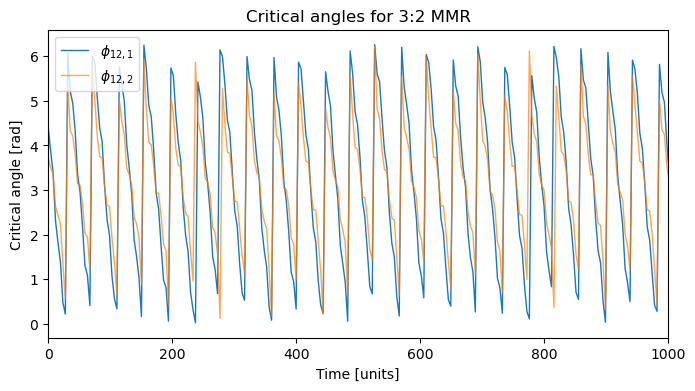

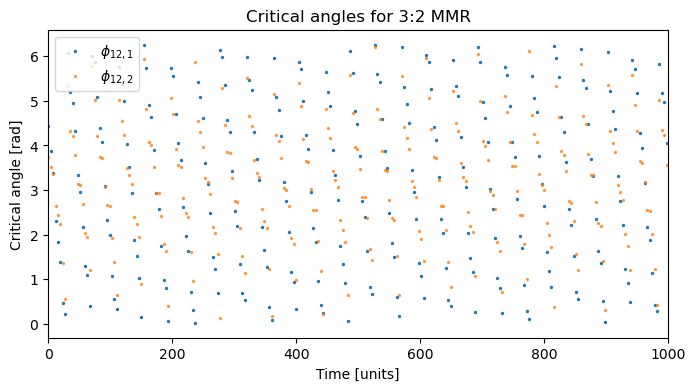

In [50]:
# Wrap angles to [-pi, pi] for easier plotting
phi1_wrapped = (phi1_vals + np.pi) % (2*np.pi) - np.pi
phi2_wrapped = (phi2_vals + np.pi) % (2*np.pi) - np.pi

phi1_wrapped = (phi1_vals) % (2*np.pi)
phi2_wrapped = (phi2_vals) % (2*np.pi)

plt.figure(figsize=(8,4))
plt.plot(times, phi1_wrapped, lw=1, label=r'$\phi_{12,1}$')
plt.plot(times, phi2_wrapped, lw=1, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(times, phi1_wrapped, s=2, label=r'$\phi_{12,1}$')
plt.scatter(times, phi2_wrapped, s=2, label=r'$\phi_{12,2}$', alpha=0.7)
plt.xlabel("Time [units]")
plt.ylabel("Critical angle [rad]")
plt.legend()
plt.title(f"Critical angles for {p[1]+1}:{p[1]} MMR")
plt.xlim(0,1000)
plt.show()

## 10 random draws from Y1 for initialization

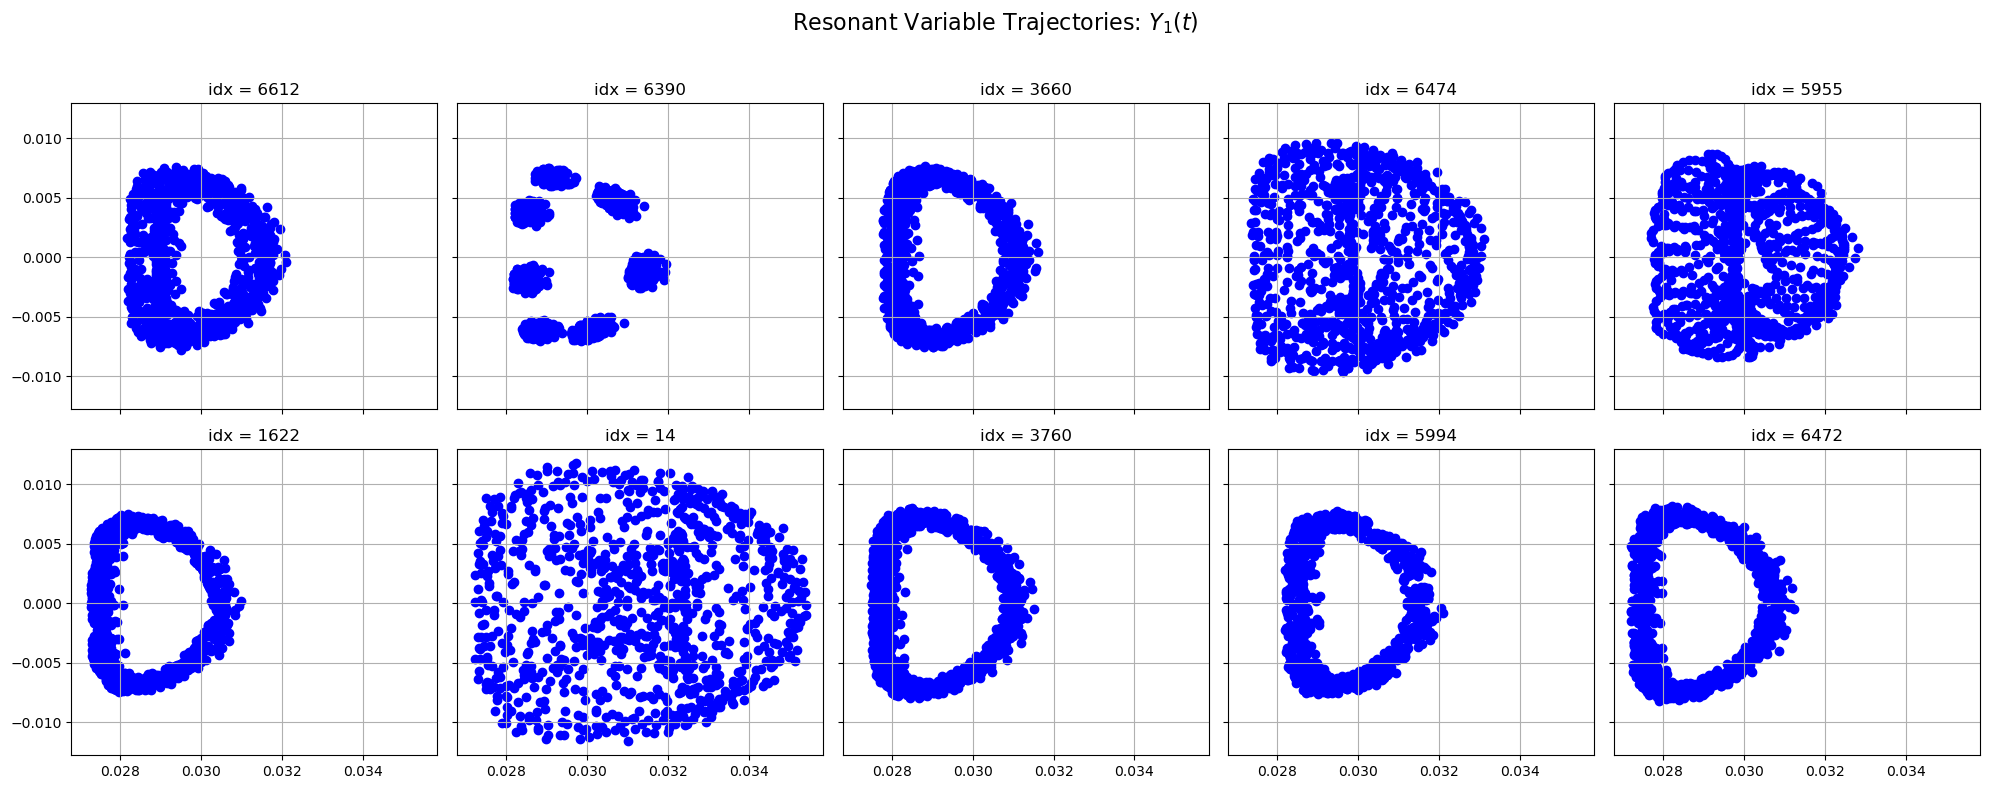

In [46]:
# index = [5000, 390, 6789]
# index = [5000, 390, 6789, 1200, 42, 888, 2345, 876, 345, 999]  # 10 samples
index = list(np.random.choice(8000, size=10, replace=False))
n_draws = len(index)

ncols = 5
nrows = (n_draws + ncols - 1) // ncols  # auto-adjust rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4), sharex=True, sharey=True)


for i, idx in enumerate(index):
    row, col = divmod(i, ncols)
    ax = axes[row, col] if nrows > 1 else axes[col]  # handle 1-row edge case

    ### initialize simulation at values near the median Y1 values
    m_b_val = m_b[idx]
    m_c_val = m_c[idx]
    a_b_val = a_b[idx]
    a_c_val = a_c[idx]
    e_b_val = e_b[idx]
    e_c_val = e_c[idx]
    lambda_b_val = lambda_b[idx]
    lambda_c_val = lambda_c[idx]
    pomega_b_val = pomega_b[idx]
    pomega_c_val = pomega_c[idx]
    P_b_val = P_b[idx]
    
    ### time settings 
    t_max = 1e4 * P_b_val
    Nout = 1000
    times = np.linspace(0,t_max,Nout)
    
    sim = rebound.Simulation()
    sim.add(m=m_star)
    
    ### initialize with median values from posteriors?
    sim.add(m=m_b_val, a=a_b_val, e=e_b_val, l=lambda_b_val, pomega=pomega_b_val)
    sim.add(m=m_c_val, a=a_c_val, e=e_c_val, l=lambda_c_val, pomega=pomega_c_val)
    
    sim.move_to_com()
    
    H_vals = np.zeros(len(times))
    Re_Y1_vals = np.zeros(len(times))
    Im_Y1_vals = np.zeros(len(times))
    Re_Y2_vals = np.zeros(len(times))
    Im_Y2_vals = np.zeros(len(times))
    I1_vals = np.zeros(len(times))
    I2_vals = np.zeros(len(times))
    theta1_vals = np.zeros(len(times))
    
    for i, t in enumerate(times):
        sim.integrate(t)
        H_t, Y1_t, Y2_t, I1_t, I2_t, theta1_t, eb_1, ec_t, Delta_pomega_t = compute_resonant_vars(sim)
        # print(Y1)
        H_vals[i] = H_t
        Re_Y1_vals[i] = np.real(Y1_t)
        Im_Y1_vals[i] = np.imag(Y1_t)
        Re_Y2_vals[i] = np.real(Y2_t)
        Im_Y2_vals[i] = np.imag(Y2_t)
        I1_vals[i] = I1_t
        I2_vals[i] = I2_t
        theta1_vals[i] = theta1_t

    ax.scatter(Re_Y1_vals, Im_Y1_vals, lw=1, color='blue')
    ax.set_title(f'idx = {idx}')
    ax.grid(True)

# Clean up unused subplots if n_draws < nrows*ncols
for i in range(n_draws, nrows * ncols):
    row, col = divmod(i, ncols)
    fig.delaxes(axes[row, col] if nrows > 1 else axes[col])

fig.suptitle(r'Resonant Variable Trajectories: $Y_1(t)$', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Just Y1 and Y2 trajectories 

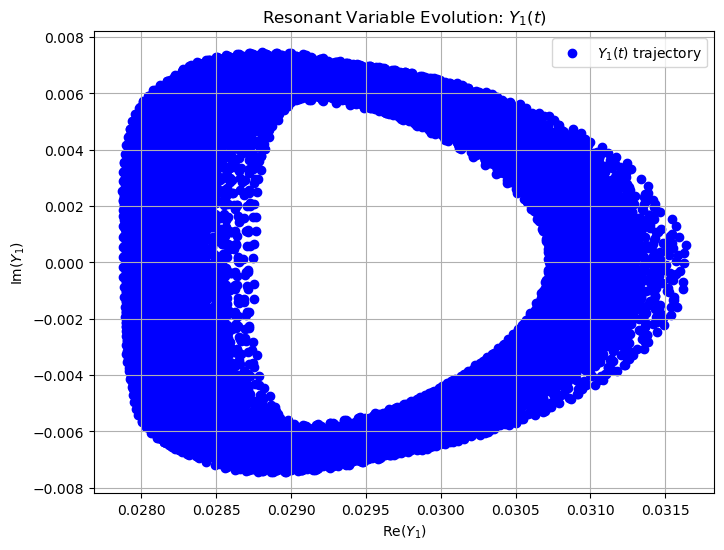

In [42]:
# Plot Y1 in Re/Im space
plt.figure(figsize=(8,6))
plt.scatter(Re_Y1_vals, Im_Y1_vals, c='blue', lw=1, label=r'$Y_1(t)$ trajectory')
plt.xlabel(r'Re$(Y_1)$')
plt.ylabel(r'Im$(Y_1)$')
plt.title(r'Resonant Variable Evolution: $Y_1(t)$')
plt.grid(True)
plt.legend()
plt.show()

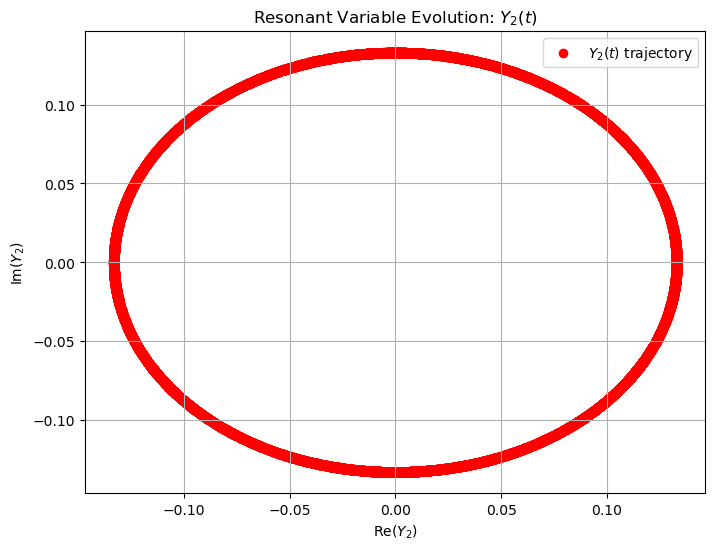

In [43]:
# Plot Y2 in Re/Im space
plt.figure(figsize=(8,6))
plt.scatter(Re_Y2_vals, Im_Y2_vals, c='red', lw=1, label=r'$Y_2(t)$ trajectory')
plt.xlabel(r'Re$(Y_2)$')
plt.ylabel(r'Im$(Y_2)$')
plt.title(r'Resonant Variable Evolution: $Y_2(t)$')
plt.grid(True)
plt.legend()
plt.show()

# Distance to Resonance

In [47]:
nb = (2*np.pi) / P_b
nc = (2*np.pi) / P_c

delta = ((p*nb) / ((p+1)*nc)) - 1
print(f"delta: {delta}")
print(f"median delta: {np.median(delta)}")

precess_frequency = -nc*delta*(p+1)
print(f"precession frequency: {precess_frequency}")
print(f"median precession frequency: {np.median(precess_frequency)}")

delta: [0.00251544 0.00250912 0.00248253 ... 0.00238073 0.00233769 0.00226796]
median delta: 0.0023082494735717773
precession frequency: [-0.00398164 -0.00397165 -0.00392965 ... -0.00376882 -0.00370084
 -0.00359062]
median precession frequency: -0.003654270665720105


In [48]:
print(f'Delta_pomega: {Delta_pomega}')
print(f'Median Delta_pomega: {np.median(Delta_pomega)}')
print(f'e_b: {e_b}')
print(f'median e_b: {np.median(e_b)}')
print(f'e_c: {e_c}')
print(f'median e_c: {np.median(e_c)}')

Delta_pomega: [ 0.91450578  0.98758882  0.31374538 ... -0.99816442 -0.86676598
 -0.4462347 ]
Median Delta_pomega: -0.25339275598526
e_b: [0.07385355 0.07307937 0.0699259  ... 0.03138006 0.04694087 0.08037299]
median e_b: 0.09561829268932343
e_c: [0.0135331  0.01514867 0.00397953 ... 0.06228583 0.06918973 0.10519482]
median e_c: 0.09719006717205048


In [49]:
print('Median values:')
print(f'abs(Y1): {np.median(np.abs(Y1))}')
print(f'1.22*abs(Y2): {np.median(1.22*np.abs(Y2))}')

print(f'1.07*gamma*abs(Y1): {np.median(1.07*gamma*np.abs(Y1))}')
print(f'abs(Y2): {np.median(np.abs(Y2))}')

Median values:
abs(Y1): 0.030506033807805907
1.22*abs(Y2): 0.21038363873958588
1.07*gamma*abs(Y1): 0.0918971598148346
abs(Y2): 0.17244559526443481


# Eccentricity evolution

In [50]:
def ecc_b_(Y1, Y2, gamma, pomega_b, theta_res):
    ecc_b = ((Y1 + 1.22*Y2)/(np.sqrt(1 + 1.31*gamma))) #* np.exp(-1j*(pomega_b-theta_res))
    return ecc_b

def ecc_c_(Y1, Y2, gamma, pomega_c, theta_res):
    ecc_c = ((-1.07*gamma*Y1 + Y2)/(np.sqrt(1+1.31*gamma))) #* np.exp(-1j *(pomega_c-theta_res))
    return ecc_c

def ecc_aprox_b_(t, t0, Y1_initial, Y2_initial, P_b, P_c):
    nb = (2*np.pi)/P_b
    nc = (2*np.pi)/P_c
    delta = (2*nb)/(3*nc) - 1
    v_theta = -3*delta*nc
    ecc_approx_b = (0.46*Y1_initial*np.exp(-1j*v_theta*(t-t0)) + 0.56*Y2_initial) #* np.exp(-1j*pomega_b)
    return ecc_approx_b

def ecc_aprox_c_(t, t0, Y1_initial, Y2_initial, P_b, P_c):
    nb = (2*np.pi)/P_b
    nc = (2*np.pi)/P_c
    delta = (2*nb)/(3*nc) - 1
    v_theta = -3*delta*nc
    ecc_approx_c = (-1.40*Y1_initial*np.exp(-1j*v_theta*(t-t0)) + 0.46*Y2_initial) #* np.exp(-1j*pomega_c)
    return ecc_approx_c

In [51]:
def Y1_tilda_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, theta_res, gamma):
    numerator = e_tilda_1*np.exp(1j * pomega_1) - 1.22*e_tilda_2*np.exp(1j * pomega_2)
    denominator = np.sqrt(1 + 1.31*gamma)
    Y1 = numerator/denominator #* np.exp(-1j * theta_res)
    return Y1

def Y2_tilda_(e_tilda_1, e_tilda_2, pomega_1, pomega_2, theta_res, gamma):
    numerator = 1.07*gamma*e_tilda_1*np.exp(1j * pomega_1) + e_tilda_2*np.exp(1j * pomega_2)
    denominator = np.sqrt(1 + 1.31*gamma)
    Y2 = numerator/denominator #* np.exp(-1j * theta_res)
    return Y2

In [52]:

t = np.linspace(1980., 5500., 8000)
Tc_b_med = Tc_b[median_idx]
P_b_med = P_b[median_idx]
e_tilda_b_med = e_tilda_b[median_idx]
e_b_med = e_b[median_idx]
pomega_b_med = pomega_b[median_idx]

Tc_c_med = Tc_c[median_idx]
P_c_med = P_c[median_idx]
e_tilda_c_med = e_tilda_c[median_idx]
e_c_med = e_c[median_idx]
pomega_c_med = pomega_c[median_idx]

theta_res_med = theta_res[median_idx]
gamma_med = gamma[median_idx]
Y1_initial = Y1_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)
Y2_initial = Y2_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)


ecc_aprox_b = ecc_aprox_b_(t, Tc_b_med, Y1_initial, Y2_initial, P_b_med, P_c_med)
ecc_aprox_c = ecc_aprox_c_(t, Tc_c_med, Y1_initial, Y2_initial, P_b_med, P_c_med)

ecc_b = ecc_b_(Y1, Y2, gamma_med, pomega_b_med, theta_res_med)
ecc_c = ecc_c_(Y1, Y2, gamma_med, pomega_c_med, theta_res_med)

Y1 initial: (-0.008170423071014458+0.029382989580390588j)
Y2 initial: (-0.11217635124921799-0.07130517810583115j)


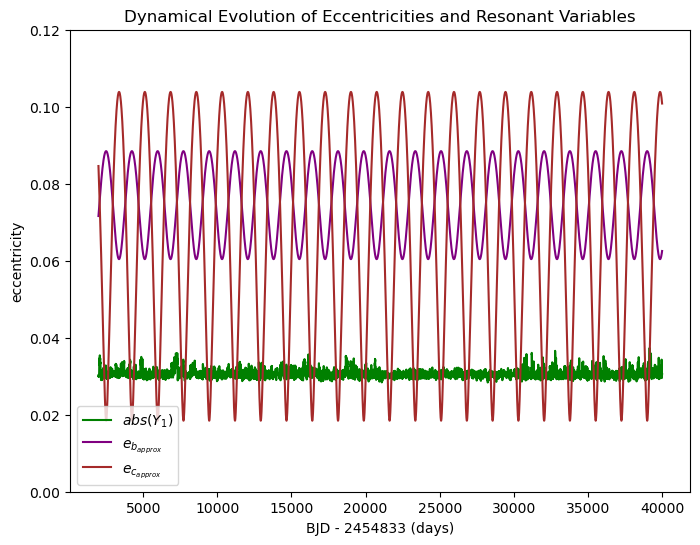

In [53]:
### approximated eccentricity evolution
t = np.linspace(1980., 40000., 8000)
Y1_initial = Y1_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)
Y2_initial = Y2_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)
print(f'Y1 initial: {Y1_initial}')
print(f'Y2 initial: {Y2_initial}')
ecc_aprox_b = ecc_aprox_b_(t, Tc_b_med, Y1_initial, Y2_initial, P_b_med, P_c_med)
ecc_aprox_c = ecc_aprox_c_(t, Tc_c_med, Y1_initial, Y2_initial, P_b_med, P_c_med)

plt.figure(figsize=(8,6))
# plt.plot(t, np.abs(ecc_b), color='blue', label='$e_b$')
# plt.plot(t, np.abs(ecc_c), color='orange', label='$e_c$')

plt.plot(t, np.abs(Y1), color='green', label='$abs(Y_1)$')
# plt.plot(t, np.abs(Y2), color='red', label='$abs(Y_2)$')
plt.plot(t, np.abs(ecc_aprox_b), color='purple', label='$e_{b_{approx}}$')
plt.plot(t, np.abs(ecc_aprox_c),color='brown', label='$e_{c_{approx}}$')

plt.title('Dynamical Evolution of Eccentricities and Resonant Variables')
plt.xlabel('BJD - 2454833 (days)')
plt.ylabel('eccentricity')
plt.ylim(0,0.12)
plt.legend()
plt.show()

Y1 initial: (0.03001324221529957+0.005415654663490158j)
Y2 initial: (-0.06061675043749656+0.11829429350679184j)


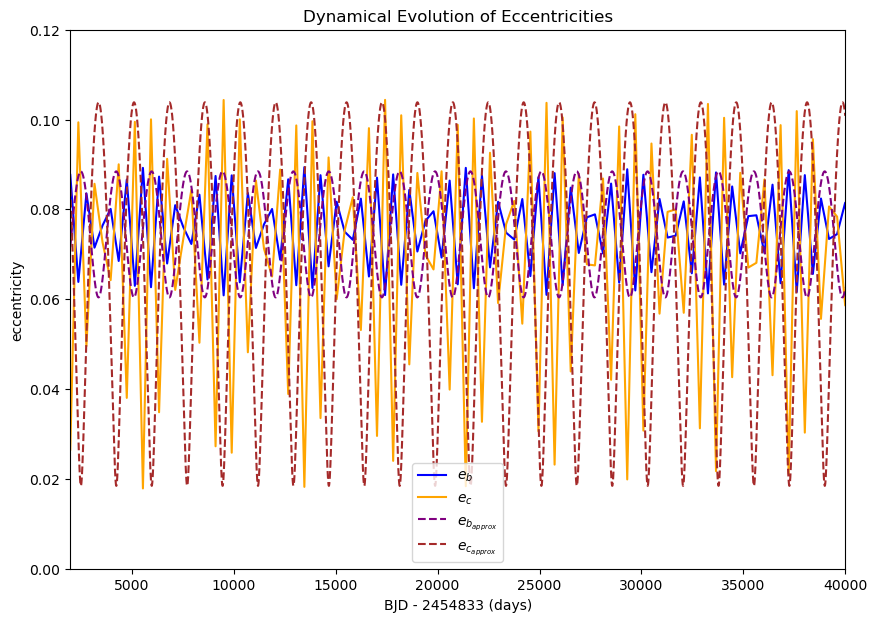

In [54]:
### approximated eccentricity evolution
t = np.linspace(1980., 40000., 8000)
t_ecc = np.linspace(0, t_max, Nout)
# Y1_initial = Y1_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)
Y1_initial = Y1i

# Y2_initial = Y2_tilda_(e_tilda_b_med, e_tilda_c_med, pomega_b_med, pomega_c_med, theta_res_med, gamma_med)
Y2_initial = Y2i
print(f'Y1 initial: {Y1_initial}')
print(f'Y2 initial: {Y2_initial}')
ecc_aprox_b = ecc_aprox_b_(t, Tc_b_med, Y1_initial, Y2_initial, P_b_med, P_c_med)
ecc_aprox_c = ecc_aprox_c_(t, Tc_c_med, Y1_initial, Y2_initial, P_b_med, P_c_med)

# Y1_rebound = Re_Y1_vals + 1j*Im_Y1_vals
# Y2_rebound = Re_Y2_vals + 1j*Im_Y2_vals
# ecc_b = ecc_b_(Y1_rebound, Y2_rebound, gamma_med, pomega_b_med, theta_res_med)
# ecc_c = ecc_c_(Y1_rebound, Y2_rebound, gamma_med, pomega_c_med, theta_res_med)
plt.figure(figsize=(10,7))
plt.plot(t_ecc, abs(eb_vals), color='blue', label='$e_b$')
plt.plot(t_ecc, abs(ec_vals), color='orange', label='$e_c$')

# plt.plot(t, np.abs(Y1), color='green', label='$abs(Y_1)$')
# plt.plot(t, np.abs(Y2), color='red', label='$abs(Y_2)$')

plt.plot(t, np.abs(ecc_aprox_b), color='purple',linestyle='--', label='$e_{b_{approx}}$')
plt.plot(t, np.abs(ecc_aprox_c),color='brown', linestyle='--', label='$e_{c_{approx}}$')

plt.title('Dynamical Evolution of Eccentricities')
plt.xlabel('BJD - 2454833 (days)')
plt.ylabel('eccentricity')
plt.xlim(1980,40000)
plt.ylim(0, 0.12)
plt.legend()

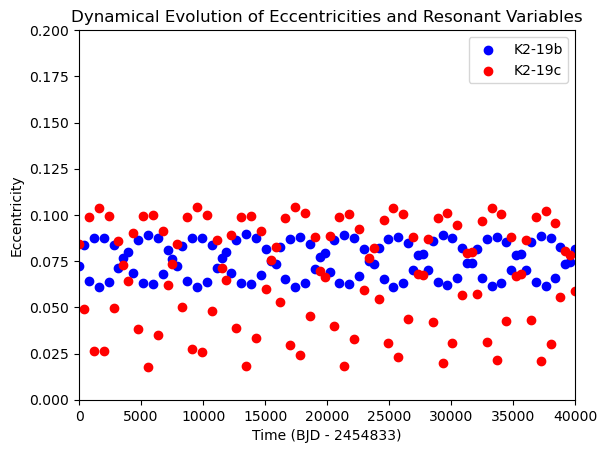

In [55]:
# Plot
plt.scatter(t_ecc, (eb_vals), color='blue', label='K2-19b')
plt.scatter(t_ecc, (ec_vals), color='red', label='K2-19c')

plt.title('Dynamical Evolution of Eccentricities and Resonant Variables')
plt.xlabel('Time (BJD - 2454833)')  # Proper LaTeX formatting
plt.ylabel('Eccentricity')
plt.xlim(0, 40000)  # Force x-axis limits
plt.ylim(0, 0.2)
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (20000,) and (8000,)

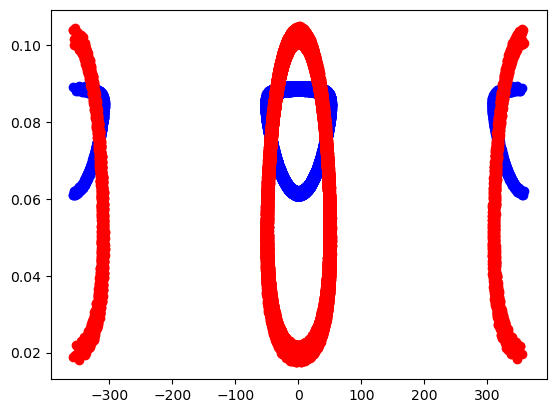

In [56]:
# Convert to [-π, π] range, then to degrees
# Delta_pomega_deg = np.degrees(np.angle(np.exp(1j * Delta_pomega_vals)))
Delta_pomega_deg = np.degrees(Delta_pomega_vals)
# Plot
plt.scatter(Delta_pomega_deg, eb_vals, color='blue', label='K2-19b')
plt.scatter(Delta_pomega_deg, ec_vals, color='red', label='K2-19c')
plt.plot(Delta_pomega_deg, np.abs(ecc_aprox_b), color='purple',linestyle='--', label='$e_{b_{approx}}$')
plt.plot(Delta_pomega_deg, np.abs(ecc_aprox_c),color='brown', linestyle='--', label='$e_{c_{approx}}$')

         
plt.title('Dynamical Evolution of Eccentricities and Resonant Variables')
plt.xlabel(r'$\Delta \varpi$ [deg]')  # Proper LaTeX formatting
plt.ylabel('Eccentricity')
plt.xlim(-180, 180)  # Force x-axis limits
plt.ylim(0, 0.2)
plt.legend()
plt.show()

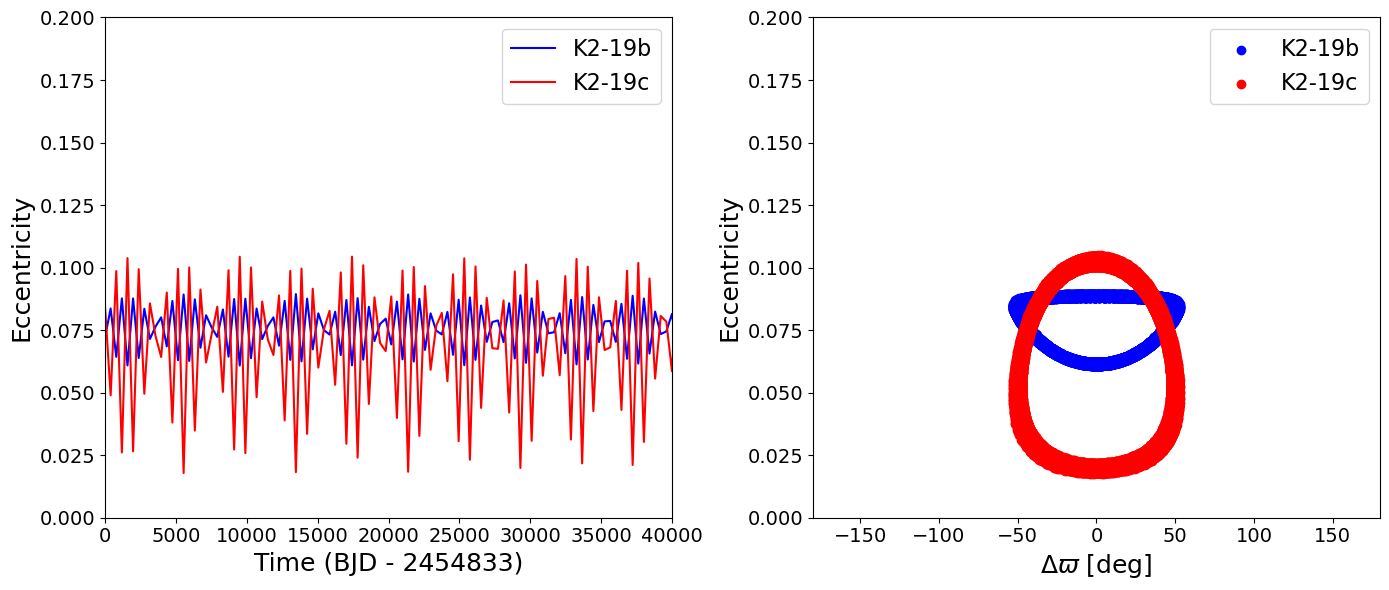

In [57]:
### combine figure 
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Font size setting
label_fontsize = 18
title_fontsize = 16
tick_fontsize = 14
legend_fontsize = 16

# First subplot: Line plots
ax1.plot(t_ecc, eb_vals, color='blue', label='K2-19b')
ax1.plot(t_ecc, ec_vals, color='red', label='K2-19c')
# ax1.set_title('Dynamical Evolution of Eccentricities')
ax1.set_xlabel('Time (BJD - 2454833)', fontsize=label_fontsize)
ax1.set_ylabel('Eccentricity', fontsize=label_fontsize)
ax1.set_xlim(0, 40000)
ax1.set_ylim(0, 0.2)
ax1.tick_params(axis='both', labelsize=tick_fontsize)
ax1.legend(fontsize=legend_fontsize)


# Second subplot: Scatter plots
ax2.scatter(Delta_pomega_deg, eb_vals, color='blue', label='K2-19b')
ax2.scatter(Delta_pomega_deg, ec_vals, color='red', label='K2-19c')
# ax2.set_title('Dynamical Evolution of Resonant Variables')
ax2.set_xlabel(r'$\Delta \varpi$ [deg]', fontsize=label_fontsize)
ax2.set_ylabel('Eccentricity', fontsize=label_fontsize)
ax2.set_xlim(-180, 180)
ax2.set_ylim(0, 0.2)
ax2.tick_params(axis='both', labelsize=tick_fontsize)
ax2.legend(fontsize=legend_fontsize)

# Adjust layout and display the figure
plt.tight_layout()
plt.show()